# M12: Data Splitting and Evaluation

In [4]:
# Importing libraries  
import tensorflow as tf
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sklearn


Using fashion_mnist dataset from Keras where the images are black and white with 10 different labels that are stored in cass_names

In [5]:
# Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [6]:
# importing 
from sklearn.model_selection import train_test_split

In [7]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

In [8]:
# Rank 3 matrix
X_train_full.shape

(60000, 28, 28)

In [9]:
# lables
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Preprocessing dividing by 255 to make the number smaller to make our model faster. Adding random state and stratify when using train test split

In [10]:

X_train_full = X_train_full/255.0
X_test = X_test/255.0

X_train, X_valid, y_train, y_valid= train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)


In [11]:
# Reshaping so we have 4 dimensions for later additions to the model.
X_train = X_train.reshape(-1,28,28,1)


In [12]:
model = tf.keras.Sequential([
    tf.keras.Input(X_train.shape[1:]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation='relu'), 
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,510 (931.68 KB)

 Trainable params: 238,510 (931.68 KB)

 Non-trainable params: 0 (0.00 B)

Compiling the model with sparse_categorical_crossentropy, setting epochs, and batch size.

In [13]:
model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [14]:
epochs = 10
batch_size = 64

fitting the model and ploting history 

In [15]:
history = model.fit(
    X_train, 
    y_train,
    epochs = epochs,
    batch_size = batch_size,
    validation_data = (X_valid, y_valid)
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step - accuracy: 0.8182 - loss: 0.5189 - val_accuracy: 0.8413 - val_loss: 0.4385
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - accuracy: 0.8629 - loss: 0.3830 - val_accuracy: 0.8759 - val_loss: 0.3558
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - accuracy: 0.8753 - loss: 0.3414 - val_accuracy: 0.8820 - val_loss: 0.3366
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - accuracy: 0.8850 - loss: 0.3154 - val_accuracy: 0.8620 - val_loss: 0.3857
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - accuracy: 0.8900 - loss: 0.2991 - val_accuracy: 0.8872 - val_loss: 0.3192
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - accuracy: 0.8972 - loss: 0.2780 - val_accuracy: 0.8871 - val_loss: 0.3185
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.9018 - loss: 0.2655 - val_accuracy: 0.8946 - val_loss: 0.2995
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.9034 - loss: 0.2570 - 

<function matplotlib.pyplot.show(close=None, block=None)>

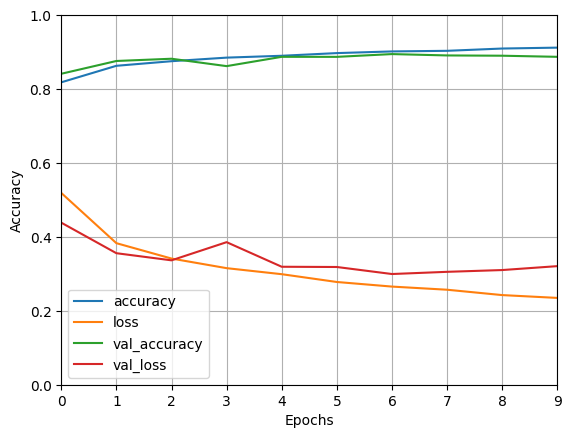

In [16]:
# Using DataFrame to plot 
pd.DataFrame(history.history).plot(
    grid=True,
    xlim=[0,9],
    ylim=[0,1],
    xlabel ="Epochs",
    ylabel = "Accuracy"
)
plt.show

In [17]:
model_eval = model.evaluate(X_test, y_test)
print(f"Loss: {round(model_eval[0], 2)}\nAccuracy {round(model_eval[1], 2)}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step - accuracy: 0.8735 - loss: 0.3558
Loss: 0.36
Accuracy 0.87


The simple model did well both accuracies going up slowly. When looking at the graph we can see that at around epoch 2 and 5 the validation data starts drops lower than the training data. The loss also validation loss jumps at nearing epoch 2, the model is fitting more to the training data.

## Data augmentation and regualirzation

Used sequential model again it was better to visualize for me.

In [18]:
# importing layers and regularizers
from tensorflow.keras import layers, regularizers

model_reg = tf.keras.Sequential([
    tf.keras.Input(X_train.shape[1:]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [19]:
model_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,510 (931.68 KB)

 Trainable params: 238,510 (931.68 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Compiling 
model_reg.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [21]:
# Fitting data
history2 = model_reg.fit(
    X_train, 
    y_train,
    epochs = 10,
    batch_size = 64,
    validation_data = (X_valid, y_valid)
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.8104 - loss: 0.7663 - val_accuracy: 0.8593 - val_loss: 0.5578
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 928us/step - accuracy: 0.8483 - loss: 0.5480 - val_accuracy: 0.8677 - val_loss: 0.4881
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 922us/step - accuracy: 0.8571 - loss: 0.4966 - val_accuracy: 0.8513 - val_loss: 0.4948
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 893us/step - accuracy: 0.8592 - loss: 0.4732 - val_accuracy: 0.8641 - val_loss: 0.4673
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.8620 - loss: 0.4632 - val_accuracy: 0.8717 - val_loss: 0.4438
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step - accuracy: 0.8654 - loss: 0.4517 - val_accuracy: 0.8783 - val_loss: 0.4255
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - accuracy: 0.8677 - loss: 0.4415 - val_accuracy: 0.8619 - val_loss: 0.4667
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 876us/step - accuracy: 0.8709 - loss: 0.4357 - 

Plotting data using regularization

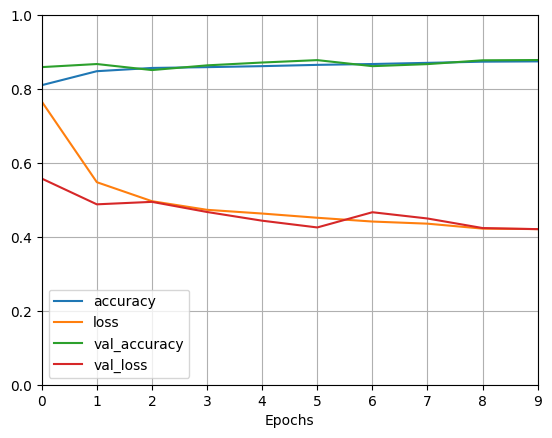

In [22]:
pd.DataFrame(history2.history).plot(
    grid=True,
    xlim=[0,9],
    ylim=[0,1],
    xlabel ="Epochs" 
)
plt.show()

This time the training data and the validation data are very close almost matching which is good for generalizing since both X_valid and X_train have an accuracy of around 85%

In [23]:
model_reg_eval = model_reg.evaluate(X_test, y_test)
print(f"Loss: {round(model_reg_eval[0], 2)}\nAccuracy {round(model_reg_eval[1], 2)}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - accuracy: 0.8616 - loss: 0.4554
Loss: 0.46
Accuracy 0.86


In [24]:
# using ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [32]:
modle_reg.fit(datagen.flow(X_train, y_train, batch_size=32))

NameError: name 'modle_reg' is not defined

With data augmentation we get around 75% accuracy and a loss of about 73% the predictions are not as accurate. 

## Modle with dropout layer & Early stopping

Adding dropout layer and using the same hyperparameters in the model

In [30]:
model_dropout = tf.keras.Sequential([
    tf.keras.Input(X_train.shape[1:]),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [ ]:
model_dropout.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [ ]:
history3 = model_dropout.fit(X_train, y_train, epochs=10, validation_data = [X_valid, y_valid])

In [ ]:
pd.DataFrame(history3.history).plot(
    grid=True,
    xlim=[0,9],
    ylim=[0,1],
    xlabel ="Epochs" 
)
plt.show()

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="auto",
    restore_best_weights=False,
    start_from_epoch=0,
)

In [ ]:
history3 = model_dropout.fit(X_train, y_train, epochs=10, validation_data = [X_valid, y_valid], callbacks = early_stopping)

## Model with flatten, dropout, regularizer, batch_normal

In [26]:
model_final = tf.keras.Sequential([
    tf.keras.Input(X_train.shape[1:]),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(250, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [27]:
model_final.compile(loss = "sparse_categorical_crossentropy",optimizer = "adam",metrics = ["accuracy"])

In [28]:
model_final.fit(datagen.flow(X_train, y_train, batch_size=32))

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6337 - loss: 1.2819


In [29]:
model.fit(X_train, y_train, epochs = epochs, batch_size = batch_size, validation_data = [X_valid, y_valid], callbacks = early_stopping)

NameError: name 'early_stopping' is not defined

In [ ]:
model_final.evaluate(X_test, y_test)